# EDA — Ocupados

---
## 0. Configuración del Dataset

In [2]:
# ============================================================
# CONFIGURACIÓN: OCUPADOS
# ============================================================

DATASET_CONFIG = {
    'nombre': 'ocupados',
    'archivo': 'ocupados_situacion_profesional_sexo.csv',
    'frecuencia_original': 'trimestral',
    'col_fecha': 'fecha',
    'variable_principal': 'tasa_empleo_ambos_sexos_total',
    'variable_principal_absoluta': 'ocupados_ambos_sexos_total',
    'variables_desgloses': [
        'ocupados_ambos_sexos_asalariados_total',
        'ocupados_ambos_sexos_asalariados_sector_privado',
        'ocupados_ambos_sexos_asalariados_sector_publico',
        'ocupados_ambos_sexos_empresarios_total',
    ],
    'columnas_numericas': [
        'ocupados_ambos_sexos_total',
        'ocupados_ambos_sexos_asalariados_total',
        'ocupados_ambos_sexos_asalariados_sector_privado',
        'ocupados_ambos_sexos_asalariados_sector_publico',
        'ocupados_ambos_sexos_empresarios_total',
        'ocupados_ambos_sexos_ayuda_negocio_familiar',
        'ocupados_ambos_sexos_miembro_cooperativa',
        'ocupados_hombres_total',
        'ocupados_mujeres_total',
    ],
    'unidades': '%',
    'unidades_absoluta': 'miles de personas',
    'notas': 'EPA, INE. Ocupados por situación profesional y sexo. Serie trimestral desde 1976Q3.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: ocupados
Variable principal:  tasa_empleo_ambos_sexos_total
Frecuencia:          trimestral
Periodo estacional:  4


---
## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}
EVENTOS['1994-01-01'] = 'Paro máx\n94'
EVENTOS['2013-03-01'] = 'Paro máx\n13'


---
## 1. Carga y Diagnóstico Básico

In [4]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

# La tasa no está en este dataset; se trae del de población (EPA, mismo índice trimestral)
_ruta_pob = RUTA_BASE / 'poblacion_relacion_actividad_economica_sexo_edad.csv'
_df_pob = pd.read_csv(_ruta_pob)
_df_pob['fecha'] = pd.to_datetime(_df_pob['fecha'])
_df_pob = _df_pob.set_index('fecha').sort_index()
df['tasa_empleo_ambos_sexos_total'] = pd.to_numeric(_df_pob['tasa_empleo_ambos_sexos_total'], errors='coerce')

Dataset: ocupados
Notas:   EPA, INE. Ocupados por situación profesional y sexo. Serie trimestral desde 1976Q3.
Shape:          (198, 32)
Rango temporal: 1976-07-01 a 2025-10-01
Observaciones:  198
Columnas:       ['año', 'trimestre', 'periodo', 'ocupados_ambos_sexos_asalariados_sector_privado', 'ocupados_ambos_sexos_asalariados_sector_publico', 'ocupados_ambos_sexos_asalariados_total', 'ocupados_ambos_sexos_ayuda_negocio_familiar', 'ocupados_ambos_sexos_empresarios_total', 'ocupados_ambos_sexos_miembro_cooperativa', 'ocupados_ambos_sexos_ocupado_otra_situacion', 'ocupados_ambos_sexos_total', 'ocupados_hombres_asalariados_sector_privado', 'ocupados_hombres_asalariados_sector_publico', 'ocupados_hombres_asalariados_total', 'ocupados_hombres_ayuda_negocio_familiar', 'ocupados_hombres_empresarios_total', 'ocupados_hombres_miembro_cooperativa', 'ocupados_hombres_ocupado_otra_situacion', 'ocupados_hombres_total', 'ocupados_mujeres_asalariados_sector_privado', 'ocupados_mujeres_asalariados_se

In [5]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,trimestre,periodo,ocupados_ambos_sexos_asalariados_sector_privado,ocupados_ambos_sexos_asalariados_sector_publico,ocupados_ambos_sexos_asalariados_total,ocupados_ambos_sexos_ayuda_negocio_familiar,ocupados_ambos_sexos_empresarios_total,ocupados_ambos_sexos_miembro_cooperativa,ocupados_ambos_sexos_ocupado_otra_situacion,ocupados_ambos_sexos_total,ocupados_hombres_asalariados_sector_privado,ocupados_hombres_asalariados_sector_publico,ocupados_hombres_asalariados_total,ocupados_hombres_ayuda_negocio_familiar,ocupados_hombres_empresarios_total,ocupados_hombres_miembro_cooperativa,ocupados_hombres_ocupado_otra_situacion,ocupados_hombres_total,ocupados_mujeres_asalariados_sector_privado,ocupados_mujeres_asalariados_sector_publico,ocupados_mujeres_asalariados_total,ocupados_mujeres_ayuda_negocio_familiar,ocupados_mujeres_empresarios_total,ocupados_mujeres_miembro_cooperativa,ocupados_mujeres_ocupado_otra_situacion,ocupados_mujeres_total,ratio_asalariados,share_empleo_publico,tasa_autoempleo,share_empleo_femenino,tasa_empleo_ambos_sexos_total
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1976-07-01,1976,3,1976Q3,7498.100,1358.100,8856.200,1191.800,3852.600,0.000,52.700,12777.300,5613.900,1014.800,6628.700,391.200,2474.700,0.000,33.200,9149.100,1884.200,343.300,2227.500,800.500,1377.800,0.000,19.500,3628.200,69.312,10.629,30.152,28.396,50.148
1976-10-01,1976,4,1976Q4,7460.400,1373.700,8834.100,1135.300,3767.400,0.000,51.800,12668.800,5584.000,1019.300,6603.300,354.600,2428.000,0.000,33.200,9075.400,1876.400,354.300,2230.700,780.700,1339.500,0.000,18.600,3593.300,69.731,10.843,29.738,28.363,49.647
1977-01-01,1977,1,1977Q1,7504.400,1367.300,8871.700,1105.700,3707.800,0.000,27.900,12615.600,5607.900,1015.800,6623.700,349.000,2395.900,0.000,15.300,9040.000,1896.400,351.600,2248.000,756.700,1311.900,0.000,12.500,3575.600,70.323,10.838,29.391,28.343,49.286



Últimas 3 filas:


,año,trimestre,periodo,ocupados_ambos_sexos_asalariados_sector_privado,ocupados_ambos_sexos_asalariados_sector_publico,ocupados_ambos_sexos_asalariados_total,ocupados_ambos_sexos_ayuda_negocio_familiar,ocupados_ambos_sexos_empresarios_total,ocupados_ambos_sexos_miembro_cooperativa,ocupados_ambos_sexos_ocupado_otra_situacion,ocupados_ambos_sexos_total,ocupados_hombres_asalariados_sector_privado,ocupados_hombres_asalariados_sector_publico,ocupados_hombres_asalariados_total,ocupados_hombres_ayuda_negocio_familiar,ocupados_hombres_empresarios_total,ocupados_hombres_miembro_cooperativa,ocupados_hombres_ocupado_otra_situacion,ocupados_hombres_total,ocupados_mujeres_asalariados_sector_privado,ocupados_mujeres_asalariados_sector_publico,ocupados_mujeres_asalariados_total,ocupados_mujeres_ayuda_negocio_familiar,ocupados_mujeres_empresarios_total,ocupados_mujeres_miembro_cooperativa,ocupados_mujeres_ocupado_otra_situacion,ocupados_mujeres_total,ratio_asalariados,share_empleo_publico,tasa_autoempleo,share_empleo_femenino,tasa_empleo_ambos_sexos_total
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-04-01,2025,2,2025Q2,15456.700,3521.900,18978.600,60.000,3283.100,22.500,7.100,22268.700,8291.400,1481.400,9772.800,25.600,2103.300,13.400,2.300,11878.400,7165.300,2040.500,9205.800,34.400,1179.700,9.100,4.800,10390.300,85.225,15.815,14.743,46.659,52.960
2025-07-01,2025,3,2025Q3,15575.100,3532.700,19107.800,69.400,3272.600,25.300,6.700,22387.100,8397.000,1475.000,9872.000,35.600,2112.000,13.200,1.400,11985.400,7178.100,2057.700,9235.800,33.800,1160.600,12.200,5.300,10401.700,85.352,15.780,14.618,46.463,53.098
2025-10-01,2025,4,2025Q4,15517.800,3641.400,19159.100,83.000,3294.900,25.500,9.200,22463.300,8367.000,1507.600,9874.600,33.000,2128.200,13.300,3.000,12005.800,7150.800,2133.700,9284.500,49.900,1166.700,12.200,6.300,10457.500,85.291,16.210,14.668,46.554,53.086


In [6]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
ocupados_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
ocupados_ambos_sexos_asalariados_total,0,0.000,1976-07-01,2025-10-01
ocupados_ambos_sexos_asalariados_sector_privado,0,0.000,1976-07-01,2025-10-01
ocupados_ambos_sexos_asalariados_sector_publico,0,0.000,1976-07-01,2025-10-01
ocupados_ambos_sexos_empresarios_total,0,0.000,1976-07-01,2025-10-01
ocupados_ambos_sexos_ayuda_negocio_familiar,0,0.000,1976-07-01,2025-10-01
ocupados_ambos_sexos_miembro_cooperativa,0,0.000,1976-07-01,2025-10-01
ocupados_hombres_total,0,0.000,1976-07-01,2025-10-01
ocupados_mujeres_total,0,0.000,1976-07-01,2025-10-01



Duplicados de fecha: 0


In [7]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 92 days 00:00:00
Intervalo mínimo:                      90 days 00:00:00
Intervalo máximo:                      92 days 00:00:00


---
## 2. Series Temporales

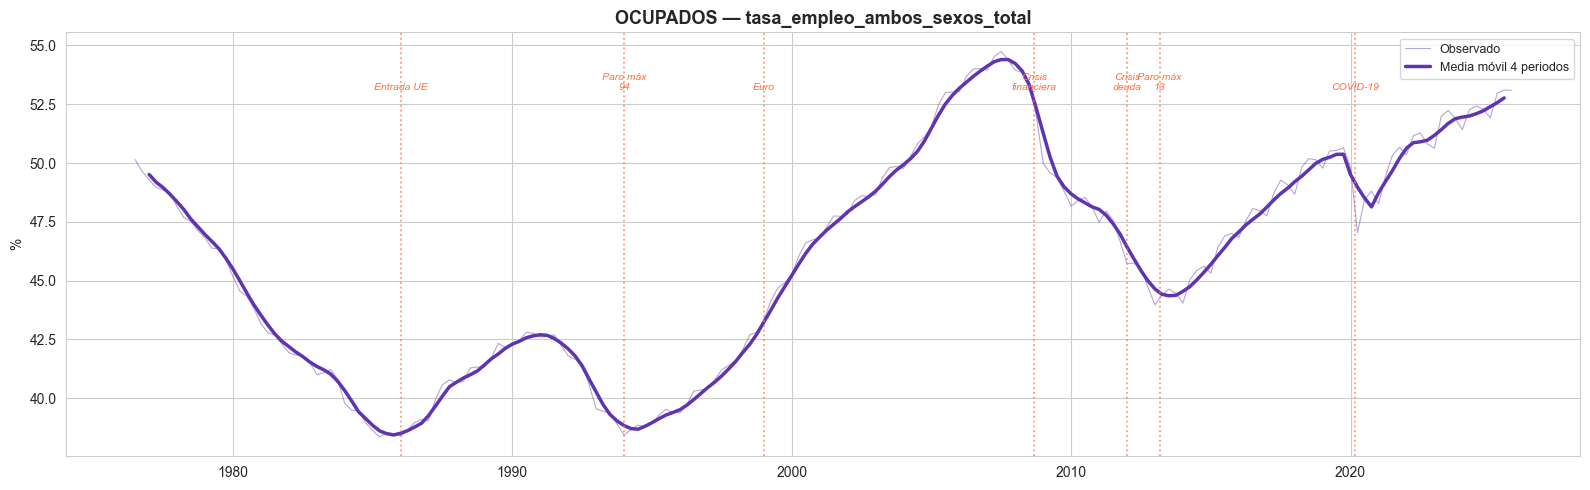

Mín: 38.35  (1985-04-01)
Máx: 54.73  (2007-07-01)


In [8]:
ventana_mm = PERIODO_ESTACIONAL

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil {ventana_mm} periodos')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

La tasa de empleo no sigue una tendencia, sino un ciclo: cae, repunta, vuelve a caer y asciende hasta un máximo histórico en 2007 que aún no ha recuperado. Toca su primer suelo en 38,35% en 1985-Q2, en el fondo de la reconversión industrial, repunta hasta aproximadamente 42,6% hacia 1991 y vuelve a hundirse hasta 38,44% en 1994-Q1 con la crisis del SME, dos mínimos separados por menos de una décima de punto. Desde ahí encadena la expansión más larga del periodo, que la lleva al techo de 54,73% en 2007-Q3 con la burbuja inmobiliaria. La crisis financiera revierte el ciclo y la devuelve a aproximadamente 44% en 2013, y la recuperación posterior, interrumpida por la caída transitoria de 2020 y su rebote, la deja en aproximadamente 53% en 2025-Q4.

Que la tasa cierre por debajo de su máximo de 2007 contrasta con la serie absoluta de ocupados, que sí marca récord al final de la muestra. La diferencia es el denominador: la población activa ha seguido creciendo, de modo que un número de ocupados sin precedentes se traduce en una tasa todavía inferior a la de hace casi dos décadas. Es la primera señal de que tasa y nivel cuentan historias distintas y exigen tratamientos distintos.

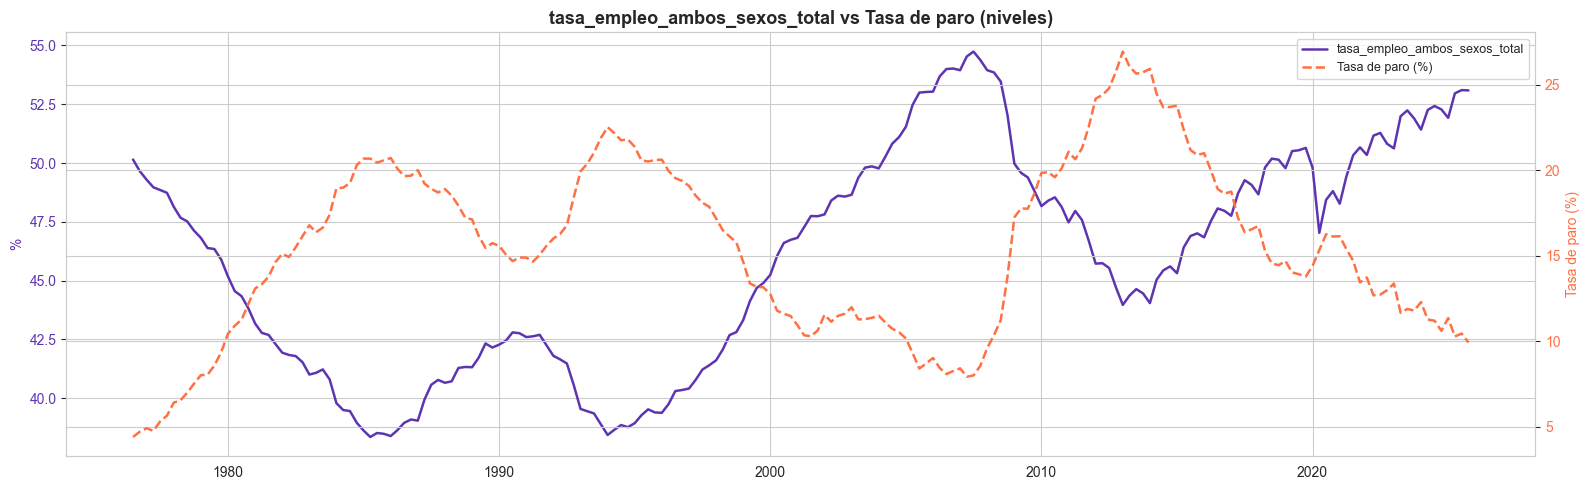

In [9]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La tasa de empleo y la tasa de paro se mueven en sentido opuesto de forma sistemática durante todo el periodo, una relación mucho más estable que la que ofrece la tasa de actividad, que apenas guarda vínculo contemporáneo con el paro. Cada fase del ciclo lo confirma sin excepción: entre 1976 y 1985 el empleo cae de aproximadamente 50% a 38,4% mientras el paro escala de aproximadamente 5% al entorno del 21%, y la crisis de 1991-1994 repite el patrón con el empleo de vuelta a 38,4% y el paro cerca del 24%. La fase expansiva 1994-2007 es la más nítida, con el empleo en 54,7% y el paro en mínimos del 8%, y las dos curvas llegan a cruzarse visualmente hacia 1999-2000. La crisis financiera invierte el movimiento con la misma intensidad, empleo hasta aproximadamente 44% y paro hasta aproximadamente 27%, antes de que ambas se relajen desde 2014 con la interrupción puntual de 2020. Esta lectura es solo descriptiva sobre los niveles; la correlación, en forma estacionaria, se mide en la sección 9.

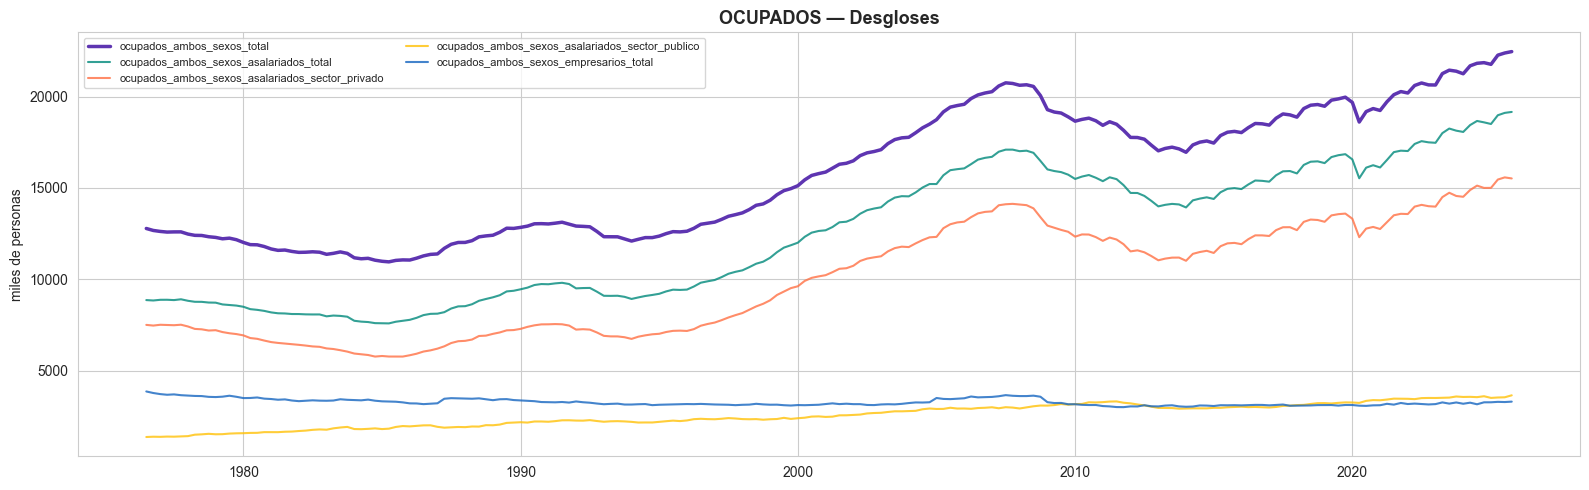

In [10]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    fig, ax = plt.subplots(figsize=(16, 5))
    VAR_ABSOLUTA = DATASET_CONFIG['variable_principal_absoluta']
    ax.plot(df[VAR_ABSOLUTA].dropna().index, df[VAR_ABSOLUTA].dropna(), color=COLOR_PRINCIPAL, lw=2.5, label=VAR_ABSOLUTA, zorder=5)

    for col, color in zip(desgloses, COLORES_DESGLOSES):
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=1.5, alpha=0.8, label=col)

    ax.set_title(f'{NOMBRE.upper()} — Desgloses', fontsize=13, fontweight='bold')
    ax.set_ylabel(DATASET_CONFIG['unidades_absoluta'], fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### Análisis:

La volatilidad cíclica del empleo total se concentra casi por completo en el asalariado privado, mientras el resto de componentes evoluciona de forma mucho más suave. El `ocupados_ambos_sexos_asalariados_sector_privado` parte de aproximadamente 7.500 miles en 1976, cae a aproximadamente 5.800 miles hacia 1985, recupera hasta aproximadamente 7.500 en 1991, retrocede a aproximadamente 6.700 en 1994 y desde ahí crece hasta aproximadamente 14.000 miles en 2007-2008. La crisis financiera le inflige la mayor contracción absoluta de toda la serie, hasta aproximadamente 11.000 miles en 2013, antes de remontar al máximo de 15.518 miles en 2025-Q4.

Los otros dos componentes apenas reaccionan al ciclo. El `ocupados_ambos_sexos_asalariados_sector_publico` dibuja una trayectoria casi monótona ascendente, de aproximadamente 1.350 a 3.641 miles, con una única pausa en 2012-2013 atribuible a la consolidación fiscal. El `ocupados_ambos_sexos_empresarios_total` se mantiene en una banda estrecha de aproximadamente 3.300 a 4.000 miles durante medio siglo y cierra en 3.295 miles, sin huella visible de las crisis.

El total agregado reproduce el perfil del privado a mayor escala, con un mínimo aproximado de 10.949 miles en 1985 y un máximo de 22.463 miles en 2025-Q4. La conclusión es directa: es el empleo asalariado privado el que canaliza las perturbaciones macroeconómicas hacia el empleo total, y el resto de categorías actúa como amortiguador.

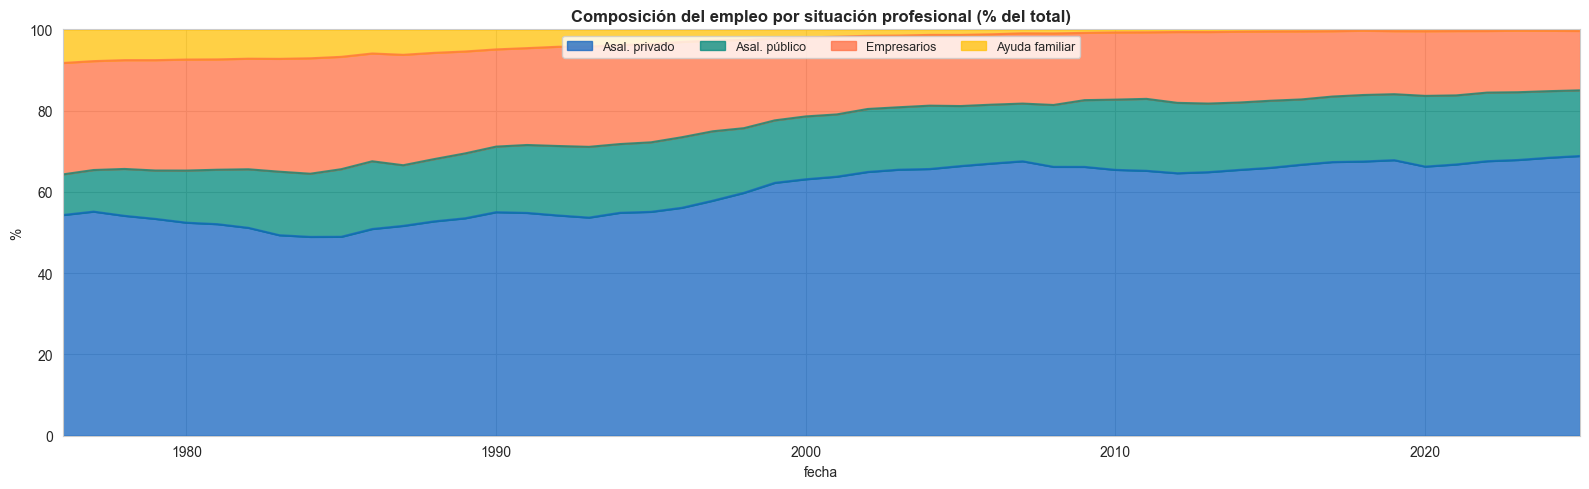

In [11]:
# Composición del empleo por situación profesional (anual)
cols_comp = {
    'Asal. privado': 'ocupados_ambos_sexos_asalariados_sector_privado',
    'Asal. público': 'ocupados_ambos_sexos_asalariados_sector_publico',
    'Empresarios': 'ocupados_ambos_sexos_empresarios_total',
    'Ayuda familiar': 'ocupados_ambos_sexos_ayuda_negocio_familiar',
}
cols_disp = {k: v for k, v in cols_comp.items() if v in df.columns}

if cols_disp:
    df_anual = df[[*cols_disp.values()]].resample('YS').last().dropna()
    df_pct = df_anual.div(df_anual.sum(axis=1), axis=0) * 100
    df_pct.columns = list(cols_disp.keys())

    fig, ax = plt.subplots(figsize=(16, 5))
    df_pct.plot.area(ax=ax, color=['#1565C0', '#00897B', '#FF7043', '#FFC107'], alpha=0.75)
    ax.set_title('Composición del empleo por situación profesional (% del total)', fontsize=12, fontweight='bold')
    ax.set_ylabel('%', fontsize=10)
    ax.legend(fontsize=9, ncol=4, loc='upper center')
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.show()

### Análisis:

La composición del empleo se ha desplazado de forma sostenida hacia la salarización. El asalariado privado, categoría dominante en todo momento, gana peso desde aproximadamente 55% en 1976 hasta aproximadamente 68% en 2025, con una aceleración entre 1995 y 2008, y el asalariado público pasa de aproximadamente 10% a una banda estabilizada en el 16-17% desde los años noventa. Sumados, ambos elevan el `ratio_asalariados` de aproximadamente 69% a 85,5% al cierre.

El avance de los asalariados se produce a costa del trabajo por cuenta propia. Los empresarios retroceden de aproximadamente 27% a aproximadamente 15%, y la ayuda familiar se desploma desde aproximadamente 8% hasta valores residuales próximos al 1%, la transformación relativa más intensa del conjunto y la más temprana, ligada al abandono de la agricultura familiar. Desde aproximadamente 2000 la composición se mantiene casi estancada, lo que sitúa la recomposición del empleo español en el cuarto de siglo previo y no en las últimas dos décadas.

---
## 3. Distribución y Outliers

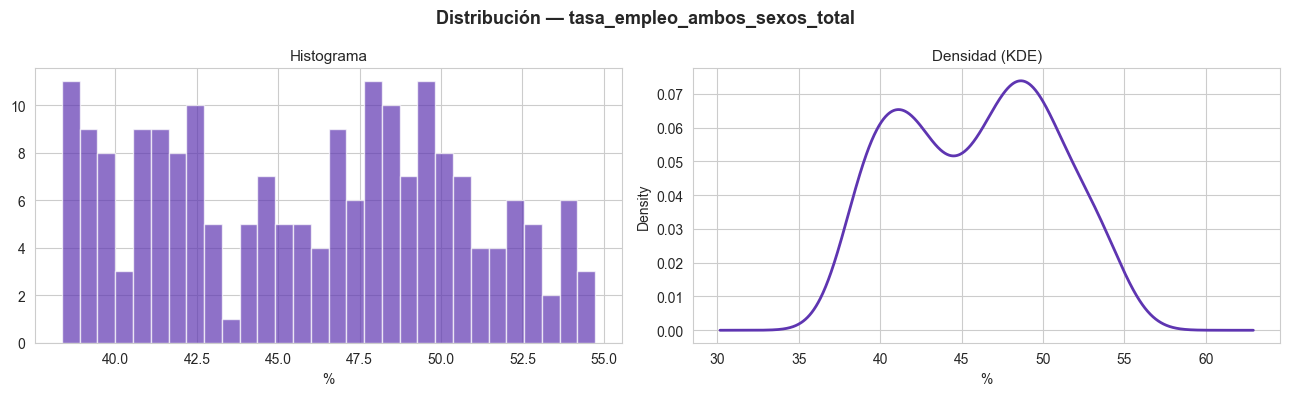

Asimetría (skewness): 0.007
Curtosis:             -1.191


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

La distribución de la tasa de empleo es bimodal, con dos modas separadas por un valle que reflejan las dos mesetas que la serie ha ocupado durante periodos largos. La moda inferior se sitúa en torno a 41% y la superior en torno a 48-49%, con un valle intermedio próximo a 44-45%. La moda alta es algo más densa que la baja (aproximadamente 0,073 frente a 0,065, leído contra la cuadrícula del KDE), lo que indica que la serie ha pasado algo más de tiempo en el régimen de empleo elevado. La asimetría es prácticamente nula (skewness 0,007) y la curtosis negativa (-1,191) describe una distribución más plana que la normal, coherente con dos máximos locales y colas ligeras.

La bimodalidad no es una propiedad estructural de la variable, sino el rastro de su recorrido cíclico. La tasa ha atravesado deprisa los valores intermedios durante las fases de expansión y contracción, dejando pocas observaciones en torno al valle, y ha permanecido en cambio largos tramos en los dos extremos. Es una distribución que hay que leer como consecuencia de la dinámica temporal, no como evidencia de dos poblaciones distintas.

In [13]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 0
Outliers por z-score (>3): 0

10 valores extremos (5 mínimos + 5 máximos):
     fecha  valor
1985-04-01 38.355
1986-01-01 38.395
1994-01-01 38.440
1985-10-01 38.490
1985-07-01 38.525
2006-07-01 53.994
2006-10-01 54.015
2007-10-01 54.376
2007-04-01 54.528
2007-07-01 54.735


### Análisis:

La serie no contiene valores atípicos, ni por el criterio IQR (1,5×) ni por z-score superior a 3, porque sus extremos son los extremos temporales del ciclo y no observaciones que se desvíen del patrón. Los cinco mínimos se agrupan entre 38,355% y 38,525%: cuatro pertenecen al fondo de la reconversión industrial (1985-Q2 a 1986-Q1) y uno al suelo de la crisis del SME (1994-Q1, 38,440%). Los cinco máximos, entre 53,994% y 54,735%, se concentran en 2006 y 2007, con el récord en 2007-Q3, en el techo de la expansión inmobiliaria. La distancia entre ambos grupos, aproximadamente 16,4 puntos porcentuales, mide la amplitud del recorrido cíclico sin generar atípicos porque las transiciones fueron graduales. El desplome de 2020 no figura entre los extremos del nivel: fue transitorio y quedó amortiguado por los ERTE, que preservaron la condición de ocupado de los trabajadores afectados.

In [14]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

La dispersión de la tasa es prácticamente idéntica en los cuatro trimestres, lo que descarta una estacionalidad relevante en este nivel de lectura. Las medianas se mueven en una banda estrecha, de 45,72% en T1 a 46,75% en T3, y los rangos intercuartílicos se solapan por completo, en torno a 41,6-50,1% en todos los casos. Esa amplitud común no procede de la estación sino del ciclo: dos observaciones del mismo trimestre en años distintos pueden distar hasta aproximadamente 16 puntos porcentuales. La única regularidad estacional es de muy baja magnitud, con T3 como trimestre de mayor empleo y T1 como el menor, y T4 algo por encima de T2, una ordenación de aproximadamente un punto sobre las medianas que apunta al empleo turístico estival. Los índices estacionales de la sección siguiente la cuantifican con precisión.

---
## 4. Estacionalidad

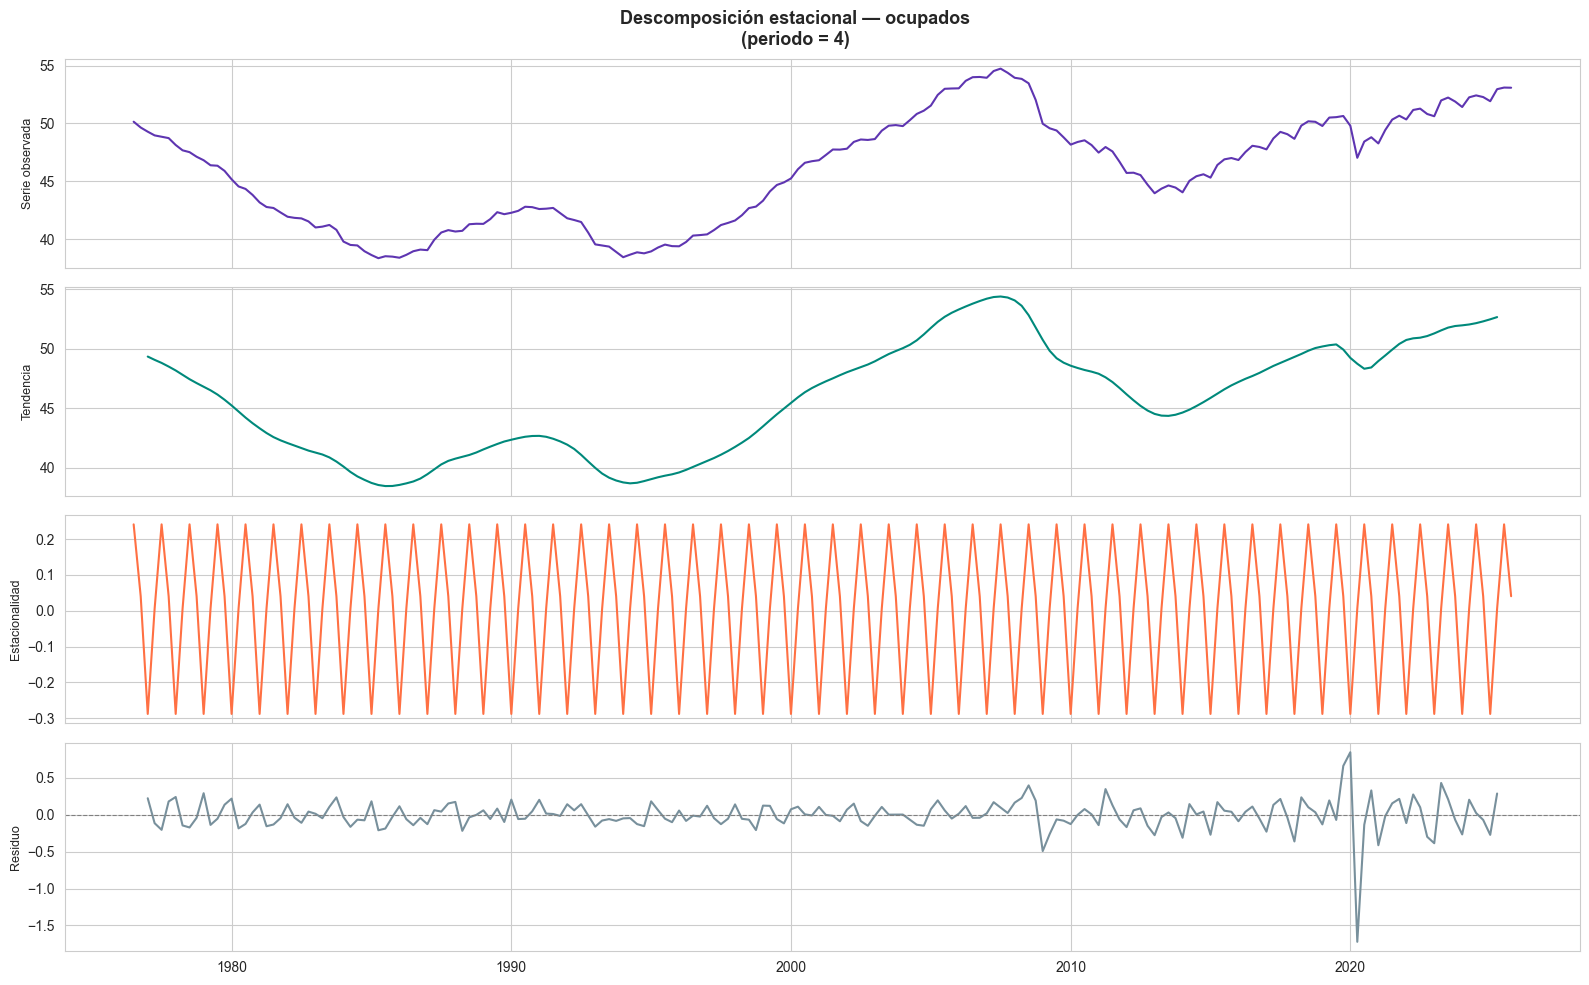

In [15]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    descomp = seasonal_decompose(y_descomp, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La tendencia es el componente que gobierna la serie y absorbe toda su ciclicidad de largo plazo: reproduce los dos suelos de 1985 y 1994, el máximo de 2007 próximo a 54,7% y la caída hasta aproximadamente 44% en 2013, seguida de la recuperación. No es una tendencia monótona, sino la espina dorsal cíclica de la tasa.

El componente estacional es regular y de amplitud constante, en torno a ±0,25 puntos porcentuales leídos contra la cuadrícula, con picos en T3 y valles en T1. Su estabilidad a lo largo de todo el periodo valida el modelo aditivo y confirma la estacionalidad modesta que ya anticipaba el boxplot.

El residuo se comporta bien hasta 2008, pequeño y centrado en cero, con oscilaciones por debajo de aproximadamente ±0,5 puntos. A partir de la crisis financiera su varianza aumenta de forma visible y alcanza el valor más extremo de la serie en 2020-Q2, una caída próxima a -1,7 puntos seguida de rebote. Que la volatilidad no capturada se concentre en torno a las crisis indica que las perturbaciones macroeconómicas golpean en los puntos de inflexión del ciclo, donde el esquema de tendencia más estacionalidad deja de ajustar bien.

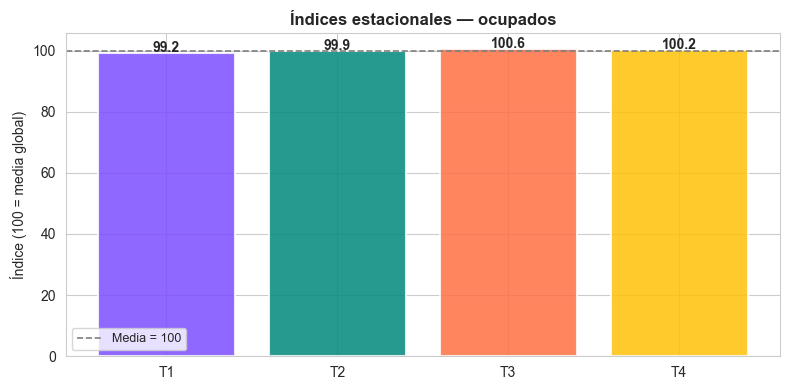

Índices estacionales:
T1    99.200
T2    99.900
T3   100.600
T4   100.200

Periodo con mayor ocupados: T3 (100.6)
Periodo con menor ocupados: T1 (99.2)


In [16]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:

Los índices estacionales confirman una estacionalidad modesta y económicamente legible: T3 es el trimestre de mayor empleo (índice 100,6) y T1 el de menor (99,2), con T4 (100,2) por encima de T2 (99,9). La diferencia entre el más alto y el más bajo, 1,4 puntos sobre base 100, equivale sobre la media de la serie (45,92%) a aproximadamente 0,64 puntos porcentuales de tasa. El patrón encaja con la estructura productiva española: T3 recoge el empleo turístico estival en hostelería, restauración y ocio, mientras T1 refleja el ajuste tras la campaña navideña. Que T4 supere a T2 sugiere que el comercio y la logística de fin de año pesan más que la primavera. La magnitud sigue siendo pequeña, de modo que la estacionalidad es real pero secundaria frente a la dinámica cíclica que domina la serie.

---
## 5. Cambios Periodo a Periodo

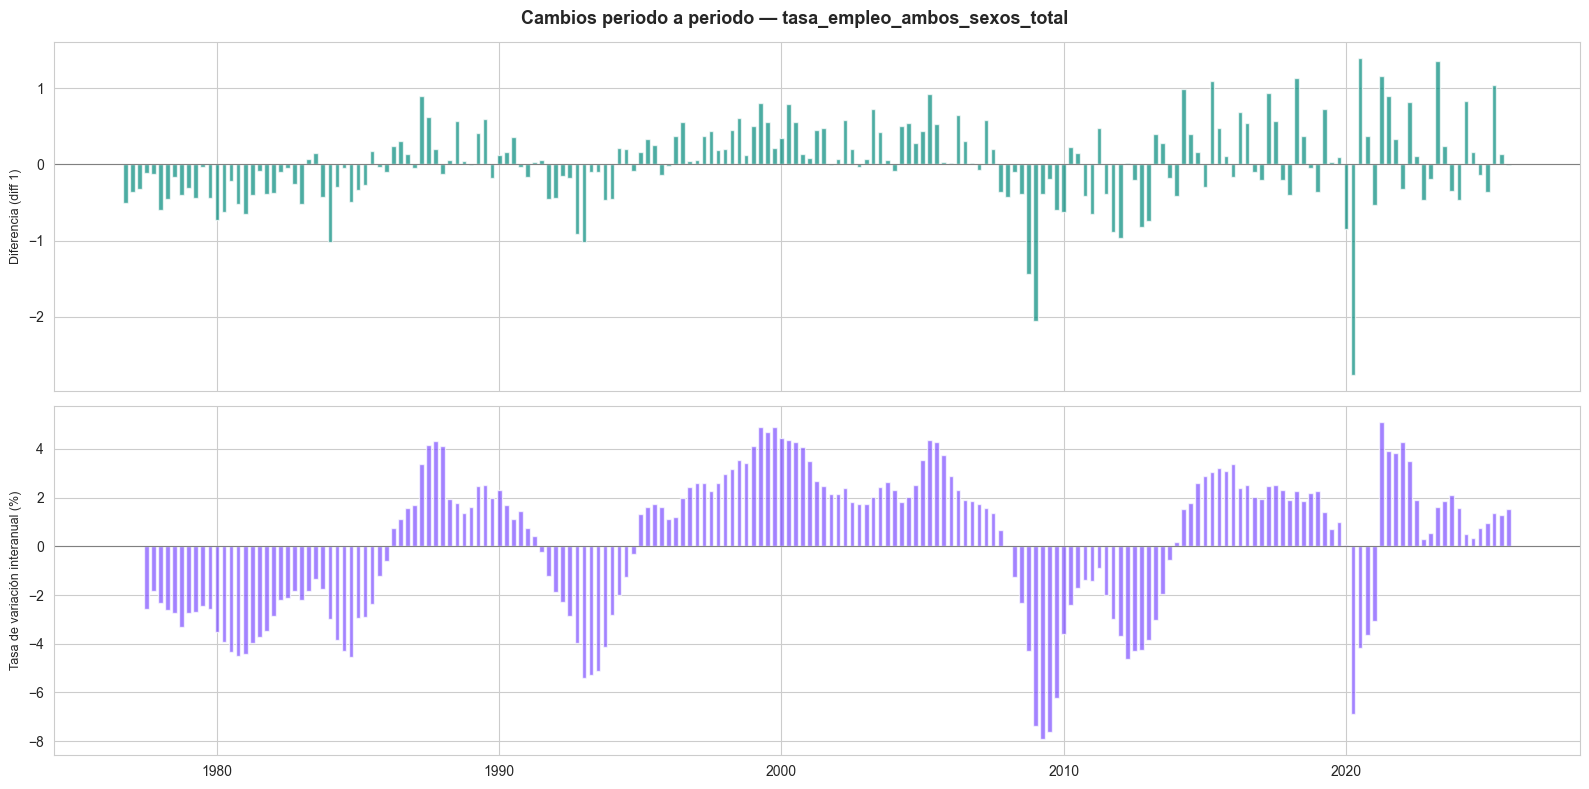

Estadísticas de la variación interanual (%):
count   194.000
mean      0.180
std       2.970
min      -7.930
25%      -2.350
50%       1.330
75%       2.380
max       5.100


In [17]:
diff1 = y.diff(1).dropna()
diff_est = y.diff(PERIODO_ESTACIONAL).dropna()  # se usa en Sección 6 (stationarity test)
pct_yoy = y.pct_change(PERIODO_ESTACIONAL).dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].bar(diff1.index, diff1, color='#00897B', alpha=0.7, width=60)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia (diff 1)', fontsize=9)

axes[1].bar(pct_yoy.index, pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Tasa de variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

La primera diferencia revela la asimetría característica del empleo español: destruye deprisa y crea despacio. El rango habitual de cambio intertrimestral se mantiene por debajo de aproximadamente ±1 punto porcentual hasta 2008 y se amplía con claridad después, con la caída más extrema de toda la serie en 2020-Q2, próxima a -2,6 puntos leídos contra la cuadrícula, seguida de un rebote cercano a +1,4 puntos en 2021.

La variación interanual sitúa esa asimetría en cifras: la media es 0,18% pero la mediana 1,33%, y esa brecha indica que las contracciones intensas tiran de la media hacia abajo. El recorrido va de -7,93% a 5,10%, con desviación típica de 2,97%, y el percentil 25 negativo (-2,35%) significa que al menos una cuarta parte de los trimestres registró caídas interanuales superiores a ese umbral. Esos episodios se concentran en las cuatro crisis del periodo: reconversión industrial de los primeros ochenta, crisis del SME de 1992-1994, crisis financiera de 2008-2013, con el mínimo de -7,93% en 2009, y el choque de 2020.

---
## 6. Estacionariedad y Autocorrelación

In [18]:
def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'ct'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (diff {PERIODO_ESTACIONAL})', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                                 serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
 tasa_empleo_ambos_sexos_total (nivel)         ct    -1.639  0.463           False      0.162   0.037             True NO ESTACIONARIA
tasa_empleo_ambos_sexos_total (diff 1)          c    -3.036  0.032            True      0.339   0.100            False    ESTACIONARIA
tasa_empleo_ambos_sexos_total (diff 4)          c    -3.267  0.016            True      0.281   0.100            False    ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  tasa_empleo_ambos_sexos_total (nivel)  (KPSS regression='ct')
    ADF  (H₀ = raíz unitaria):  stat=-1.639, p=0.4629 (NO rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=0.162, p=0.0369 (rechaza H₀)
    → NO ESTACIONARIA

  tasa_empleo_ambos_sexos_total (diff 1)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-3.036, p=0.0317 (rechaza H₀)
    KPSS (H₀ =

### Análisis:

La tasa de empleo no es estacionaria en nivel, como corresponde a una serie gobernada por un ciclo de largo plazo, y los dos contrastes coinciden en ese diagnóstico. Conviene recordar que el ADF parte de la hipótesis de raíz unitaria, de modo que no rechazarla (stat=-1,639, p=0,4629) deja la serie como no estacionaria, mientras que el KPSS parte de la hipótesis contraria, la estacionariedad, y al rechazarla (stat=0,162, p=0,0369) apunta en la misma dirección. Cuando ambos convergen, el diagnóstico es firme.

Una sola diferenciación basta para estabilizarla, y lo hace de forma limpia. En primera diferencia el ADF rechaza la raíz unitaria (stat=-3,036, p=0,0317) y el KPSS no rechaza la estacionariedad (stat=0,339, p=0,100), es decir, los dos contrastes la dan por estacionaria sin ambigüedad. La diferencia estacional ofrece el mismo resultado con márgenes algo más holgados (ADF stat=-3,267, p=0,0164; KPSS p=0,100). Frente a la serie absoluta de ocupados, donde la diferencia estacional se quedaba en zona ambigua, aquí tanto la regular como la estacional dejan la tasa estacionaria.

Se adopta la primera diferencia como forma estacionaria de referencia. Entre las dos transformaciones limpias es la más parsimoniosa, conserva más observaciones y aísla la dinámica trimestre a trimestre, que es la relevante para el cruce con la tasa de paro de la sección 9. La diferencia estacional queda como alternativa igualmente válida para los modelos que necesiten absorber la estructura de periodo cuatro que el correlograma aún revela.

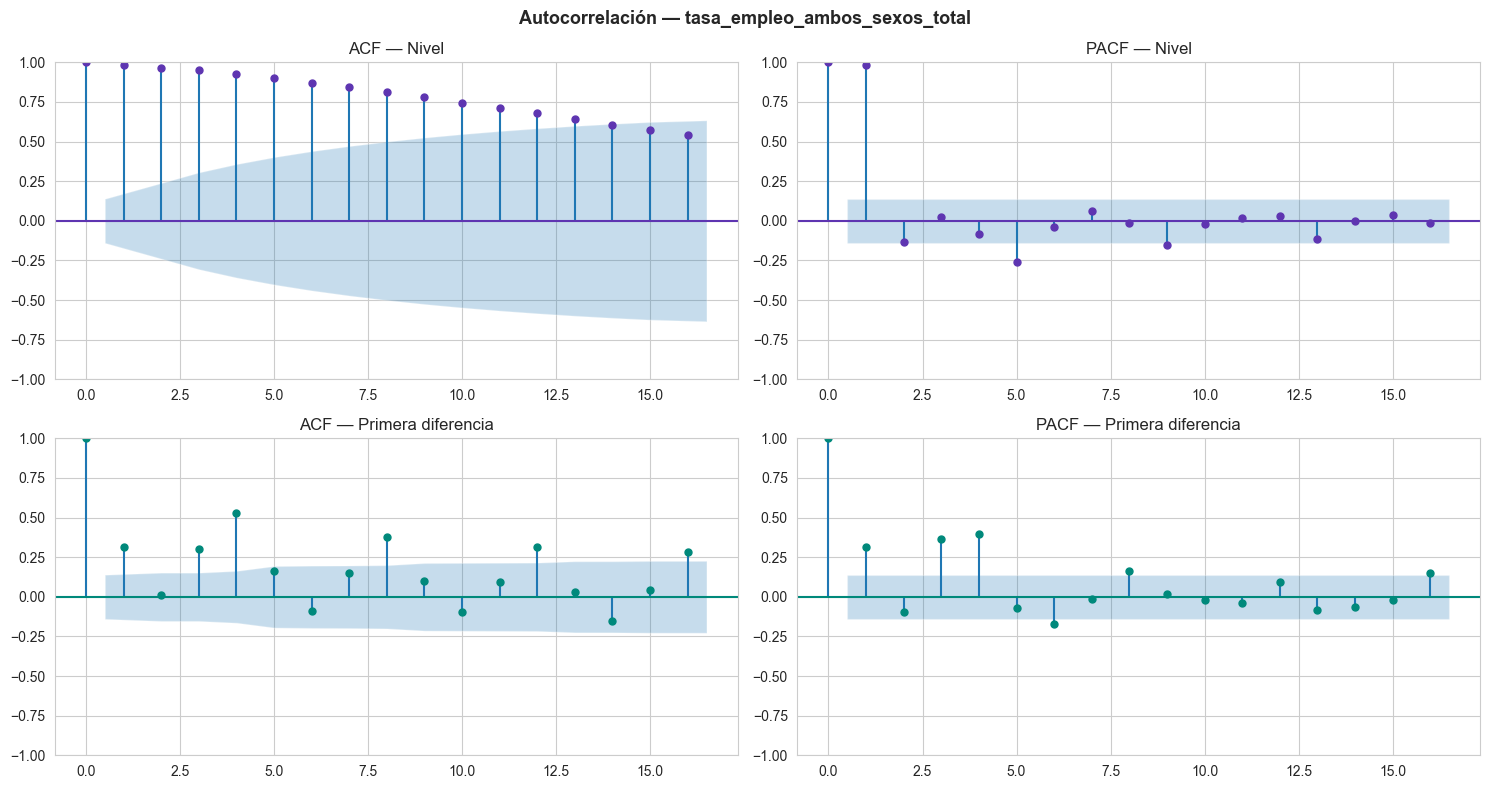

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

En nivel, el correlograma confirma visualmente la no estacionariedad que ya señalaban los tests. El ACF decae muy despacio, de aproximadamente 0,99 en el lag 1 a aproximadamente 0,55 en el lag 16 sin entrar en las bandas de confianza, el rastro típico de una raíz unitaria, y el PACF concentra casi toda la señal en un pico de lag 1 próximo a la unidad, con un pico negativo destacado en el lag 5 de aproximadamente -0,26. El conjunto describe un proceso autorregresivo de raíz muy cercana a uno.

En primera diferencia el ACF deja de decaer, pero no queda limpio: conserva picos en los múltiplos de cuatro, con el lag 4 como autocorrelación más alta del correlograma (aproximadamente 0,53) y picos menores en los lags 8 y 12. Es la firma de una estacionalidad trimestral que la diferencia regular no elimina, y el PACF lo respalda con picos en los lags 1, 3 y 4.

La lectura conjunta matiza el veredicto de los tests. La primera diferencia es estacionaria en sentido formal, pero retiene estructura estacional de periodo cuatro; la diferencia estacional, también estacionaria, la absorbe de forma más completa. Esto no cambia la forma adoptada para el cruce con el paro, sino que documenta qué componente quedará pendiente de tratar cuando la serie entre en los modelos.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [20]:
df_der = pd.DataFrame(index=df.index)

if all(c in df.columns for c in ['ocupados_ambos_sexos_asalariados_total', 'ocupados_ambos_sexos_total']):
    df_der['ratio_asalariados'] = df['ocupados_ambos_sexos_asalariados_total'] / df['ocupados_ambos_sexos_total'] * 100

if all(c in df.columns for c in ['ocupados_ambos_sexos_asalariados_sector_publico', 'ocupados_ambos_sexos_total']):
    df_der['share_empleo_publico'] = df['ocupados_ambos_sexos_asalariados_sector_publico'] / df['ocupados_ambos_sexos_total'] * 100

if all(c in df.columns for c in ['ocupados_ambos_sexos_empresarios_total', 'ocupados_ambos_sexos_total']):
    df_der['tasa_autoempleo'] = df['ocupados_ambos_sexos_empresarios_total'] / df['ocupados_ambos_sexos_total'] * 100

if all(c in df.columns for c in ['ocupados_mujeres_total', 'ocupados_ambos_sexos_total']):
    df_der['share_empleo_femenino'] = df['ocupados_mujeres_total'] / df['ocupados_ambos_sexos_total'] * 100

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (4):


,ratio_asalariados,share_empleo_publico,tasa_autoempleo,share_empleo_femenino
count,198.000,198.000,198.000,198.000
mean,77.980,16.055,21.803,37.487
std,5.625,1.621,5.449,6.911
min,68.683,10.629,14.435,27.720
25%,72.200,15.595,16.941,30.577
50%,80.061,16.322,19.831,37.029
75%,83.024,17.195,27.577,45.403
max,85.529,18.259,30.564,46.659


### Análisis:

Las cuatro variables derivadas resumen transformaciones del mercado laboral que las series brutas no muestran de forma directa. El `ratio_asalariados`, asalariados sobre total de ocupados, tiene una media de 77,98% y un rango de 68,68% a 85,53%, con una mediana de 80,06% por encima de la media que delata la acumulación de valores bajos al inicio de la muestra, cuando el autoempleo pesaba más. El `share_empleo_publico` es el más contenido y estable del grupo, con media de 16,06%, rango de 10,63% a 18,26% y la menor desviación típica del conjunto, 1,62%, en línea con la estabilidad estructural del empleo público.

Las otras dos describen movimientos de mayor amplitud y signo opuesto. La `tasa_autoempleo`, empresarios sobre total de ocupados, oscila entre 14,44% y 30,56%, con mediana de 19,83% y percentil 75 de 27,58%, lo que indica que durante buena parte del periodo el autoempleo superó el 27% antes de su retroceso. El `share_empleo_femenino` es el de recorrido más amplio, con media de 37,49%, rango de 27,72% a 46,66% y la desviación típica más alta de las cuatro, 6,91%, reflejo de un ascenso que no se detiene en toda la muestra.
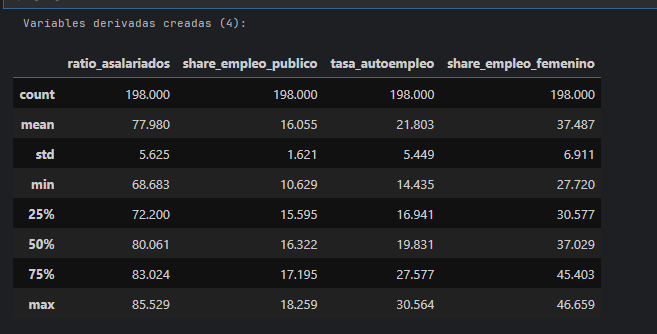

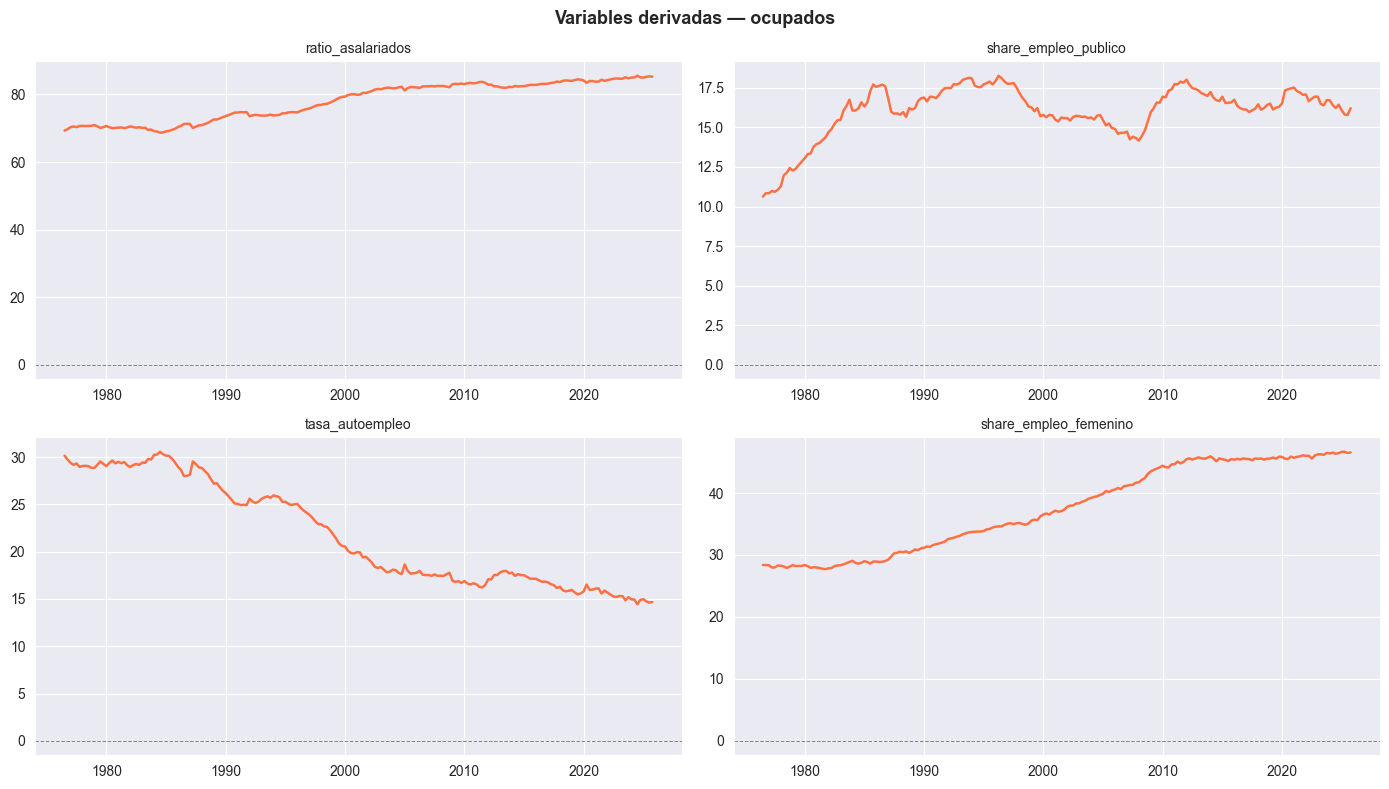

In [21]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

Las cuatro derivadas trazan tendencias estructurales de signo definido y escasa sensibilidad al ciclo. El `ratio_asalariados` sube de forma casi monótona, de aproximadamente 69% en 1977 a aproximadamente 85% en 2025, con su tramo más rápido entre 1985 y 2000 y sin reversiones cíclicas, el perfil de una salarización irreversible. El `share_empleo_publico` crece deprisa hasta una banda del 17-18% a mediados de los noventa, se estabiliza y registra una contracción visible hacia 2008 hasta aproximadamente 14% antes de recuperarse, con más variabilidad de la que sugieren sus estadísticos.

Las dos restantes se mueven en sentidos contrarios. La `tasa_autoempleo` exhibe la caída más pronunciada del conjunto, de aproximadamente 30% en 1977 a aproximadamente 15% en 2025, concentrada entre 1990 y 2005. El `share_empleo_femenino` describe el ascenso más sostenido y regular, de aproximadamente 28% a aproximadamente 47%, y documenta la incorporación continuada de la mujer al empleo a lo largo de todo el periodo.

In [22]:
# ── Guardar dataset enriquecido ───────────────────────────────────────────
if not df_der.empty:
    # Eliminar columnas derivadas antiguas que ya no se calculan
    cols_antiguas = ['ratio_publico_privado', 'brecha_genero_ocupacion']
    df = df.drop(columns=[c for c in cols_antiguas if c in df.columns], errors='ignore')
    for col in df_der.columns:
        df[col] = df_der[col]
    df.to_csv(ruta)
    print(f'CSV sobreescrito: {ruta.name}')
    print(f'  {len(df_der.columns)} variables añadidas: {list(df_der.columns)}')
    print(f'  Columnas totales: {len(df.columns)}')
else:
    print('No se crearon variables derivadas.')


CSV sobreescrito: ocupados_situacion_profesional_sexo.csv
  4 variables añadidas: ['ratio_asalariados', 'share_empleo_publico', 'tasa_autoempleo', 'share_empleo_femenino']
  Columnas totales: 32


---
## 8. Tabla Resumen

In [23]:
est_nivel = resultados_est[resultados_est['serie'].str.contains('nivel')]['conclusion'].values[0]
est_diff1 = resultados_est[resultados_est['serie'].str.contains('diff 1')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            DATASET_CONFIG['frecuencia_original'],
    'Rango':                 f'{df.index.min().date()} — {df.index.max().date()}',
    'N obs':                 len(y.dropna()),
    'Media':                 y.mean().round(2),
    'Mediana':               y.median().round(2),
    'Std':                   y.std().round(2),
    'CV (%)':                (y.std() / y.mean() * 100).round(1),
    'Mín (fecha)':           f'{y.min():.1f} ({y.idxmin().date()})',
    'Máx (fecha)':           f'{y.max():.1f} ({y.idxmax().date()})',
    'Outliers IQR':          len(outliers_iqr),
    '% faltantes':           f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':  est_nivel,
    'Estacionaria (diff 1)': est_diff1,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN
                                               Valor
Dataset                                     ocupados
Variable               tasa_empleo_ambos_sexos_total
Frecuencia                                trimestral
Rango                        1976-07-01 — 2025-10-01
N obs                                            198
Media                                         45.920
Mediana                                       46.510
Std                                            4.660
CV (%)                                        10.200
Mín (fecha)                        38.4 (1985-04-01)
Máx (fecha)                        54.7 (2007-07-01)
Outliers IQR                                       0
% faltantes                                     0.0%
Estacionaria (nivel)                 NO ESTACIONARIA
Estacionaria (diff 1)                   ESTACIONARIA
Periodo más alto                                  T3
Periodo más bajo                                  T1


### Análisis:

La tasa de empleo es una serie no estacionaria en nivel, con media de 45,92%, mediana algo superior de 46,51% y distribución prácticamente simétrica (skewness 0,007). Su coeficiente de variación, 10,2%, es muy inferior al de la serie absoluta de ocupados porque la tasa descuenta el crecimiento poblacional. El mínimo es 38,4% en 1985-Q2 y el máximo 54,7% en 2007-Q3, sin valores atípicos ni faltantes en las 198 observaciones trimestrales que van de 1976-Q3 a 2025-Q4, y la estacionalidad es leve, con T3 al alza (índice 100,6) y T1 a la baja (99,2).

El diagnóstico de estacionariedad cierra con la primera diferencia como forma adoptada. Es la transformación más simple de las que superan ambos tests (ADF p=0,0317, KPSS p=0,100), por delante de la diferencia estacional, igualmente estacionaria (ADF p=0,0164, KPSS p=0,100), que queda como alternativa para absorber la estructura de periodo cuatro que el correlograma todavía detecta. La tasa entra así en la sección 9 en primera diferencia, cruzada con la tasa de paro en su forma estacionaria.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Ocupados** y el desempleo (EPA, desde 1976Q3).

In [24]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]
df_resampled = df[[VAR_PRINCIPAL]].resample('QS').agg('mean').dropna()

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = df_resampled[VAR_PRINCIPAL].diff(1)                       # primera diferencia
main_s9_label = f'Δ1 {VAR_PRINCIPAL}'                               #
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Δ1 tasa_empleo_ambos_sexos_total
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 197


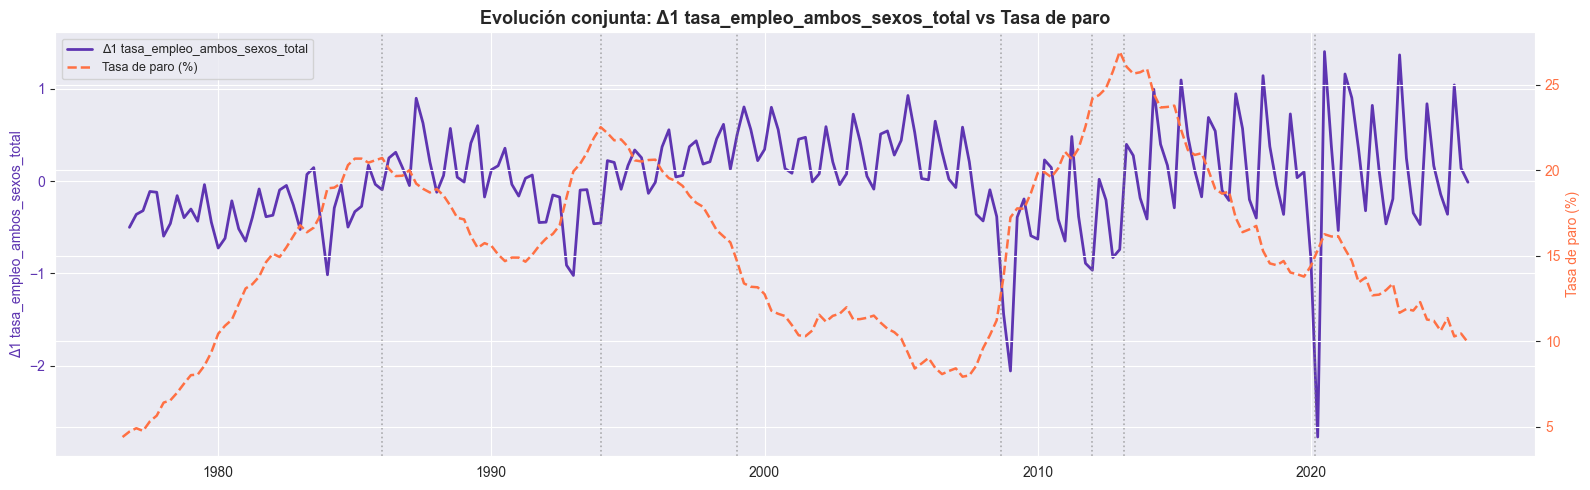

In [25]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

En forma estacionaria desaparece el co-movimiento inverso y nítido que mostraban los niveles en la sección 2. La primera diferencia de la tasa de empleo oscila como ruido cíclico en torno a cero, sin un perfil propio reconocible, mientras la tasa de paro conserva su trayectoria suave de subidas y bajadas plurianuales. Las dos series ya no se reflejan una en otra: la relación fuerte que se veía en niveles vivía en la tendencia y el ciclo compartidos, y al diferenciar el empleo esa sincronía se diluye. La amplitud de la diferencia se ensancha de forma visible a partir de 2008, en línea con el aumento de varianza documentado en la descomposición, y marca su valor más extremo en 2020-Q2, próximo a -2,6 puntos. Este gráfico es la antesala del análisis cuantitativo: anticipa que la correlación contemporánea entre ambas formas estacionarias será débil.

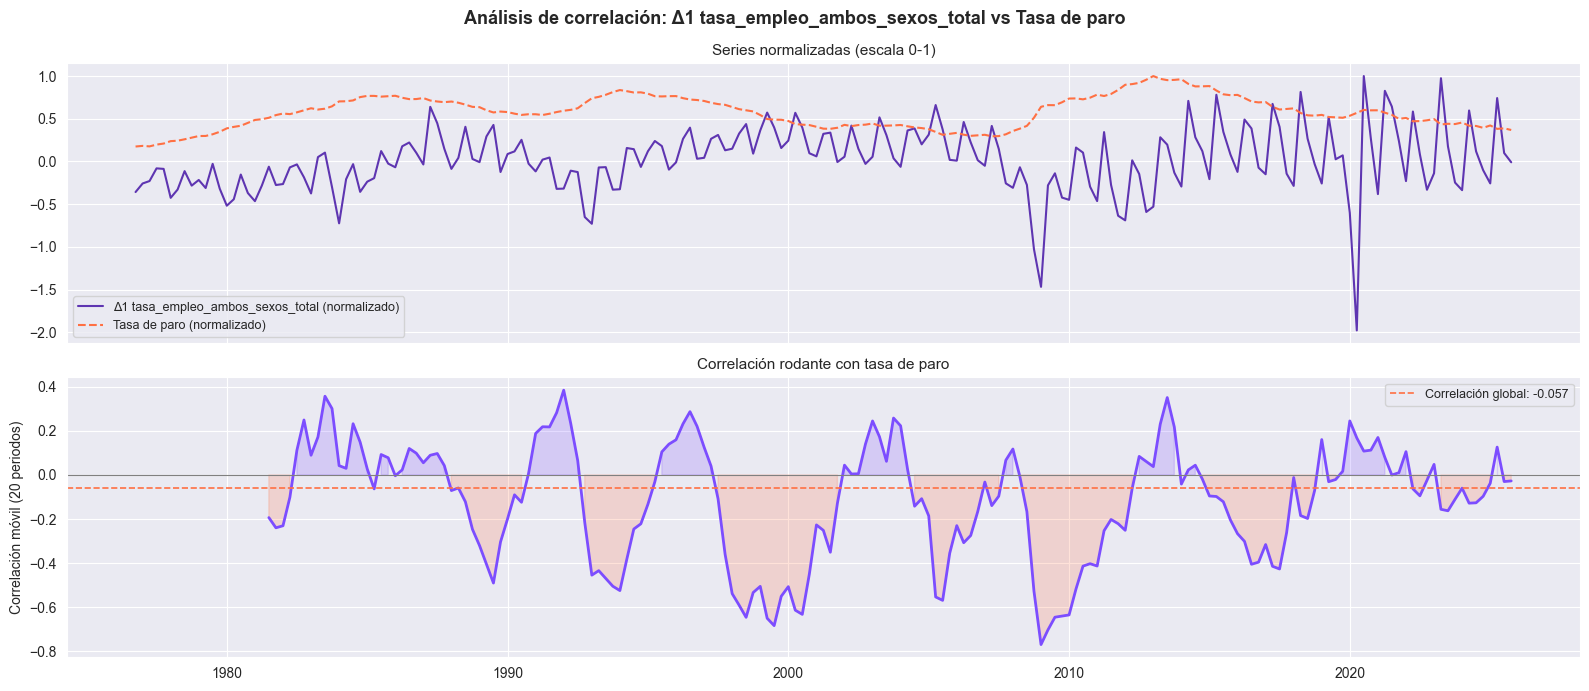

Correlación de Pearson global: -0.0571


In [26]:
ventana_corr = 20

df_cross = pd.DataFrame({'tasa_empleo': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['tasa_empleo'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['tasa_empleo'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['tasa_empleo'] / df_cross['tasa_empleo'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación global entre la primera diferencia de la tasa de empleo y la tasa de paro es prácticamente nula, con un coeficiente de Pearson de -0,0571. El resultado es esperable y no contradice la relación inversa de los niveles: una variación trimestral, que es un flujo, apenas correlaciona de forma contemporánea con un nivel, que es un stock. La fuerte asociación negativa que se observaba en la sección 2 procedía del ciclo y la tendencia comunes a ambas series, y diferenciar el empleo elimina justamente ese componente. Es la confirmación de por qué el cruce cuantitativo debe hacerse en forma estacionaria y no en nivel, donde la correlación sería espuria.

Una correlación global cercana a cero no descarta la variable, porque la rodante revela una relación que existe pero depende del régimen. Calculada sobre ventanas de 20 trimestres, oscila en un rango aproximado de -0,78 a +0,40 y cambia de signo de forma recurrente: se vuelve positiva en las fases de expansión, con máximos próximos a +0,38 hacia 1983, 1996 y 2013, y marcadamente negativa en las antesalas de las crisis, con mínimos cercanos a -0,68 hacia 2000 y a -0,78 hacia 2008-2009. La señal más intensa se concentra en los episodios recesivos, de modo que la variable conserva valor predictivo condicionado a la fase del ciclo, no como predictor de relación estable.

In [27]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='tasa_empleo', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Tasa de paro',
    labels={
        'tasa_empleo': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

### Análisis:

El diagrama de dispersión confirma visualmente la debilidad de la relación contemporánea. La recta de tendencia global tiene pendiente ligeramente negativa, coherente con el signo del coeficiente de Pearson, pero la nube de puntos es difusa y las décadas se solapan ampliamente sin formar grupos diferenciados ni alineaciones claras dentro de cada una. La primera diferencia de la tasa de empleo se reparte en una banda aproximada de -1 a +1,5 puntos para casi cualquier nivel de paro, con un par de valores extremos cercanos a -2 y -2,75 que corresponden a los choques de 2008-2009 y 2020. La ausencia de estructura, tanto global como por década, es la lectura gráfica de una correlación contemporánea próxima a cero y refuerza que la información útil de esta variable no está en su nivel de asociación instantánea con el paro.

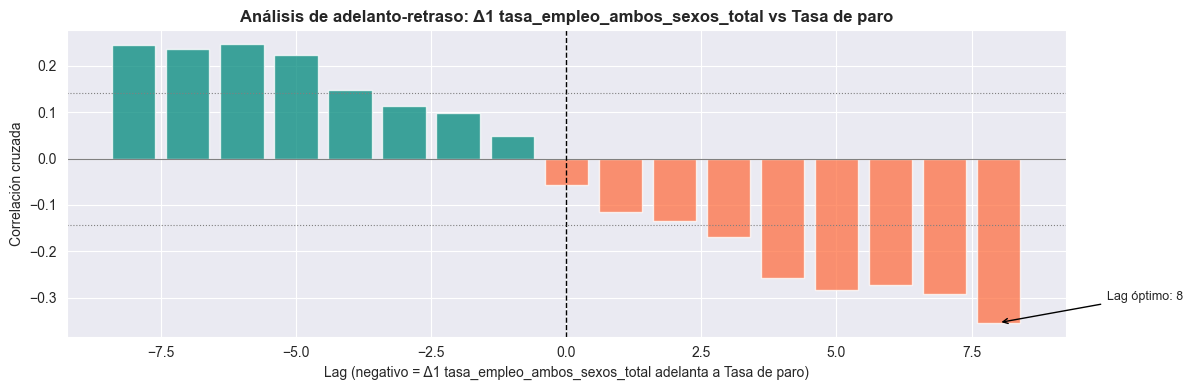

Lag con máxima correlación: 8 periodos
Correlación en ese lag: -0.3540
Banda de significancia (±2/√N): ±0.1425


In [28]:
max_lag = LAGS_ACF // 2

sa = (df_cross['tasa_empleo'] - df_cross['tasa_empleo'].mean()) / df_cross['tasa_empleo'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a Tasa de paro)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Tasa de paro', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

El perfil de correlación cruzada es asimétrico en torno al lag cero y solo alcanza intensidad apreciable en los horizontes largos. La banda de significancia, ±2/√N = ±0,1425, marca el umbral a partir del cual una correlación se distingue de cero al 95%. Cuando la variación del empleo adelanta al paro (lags negativos), la correlación es positiva y se vuelve significativa en los horizontes de seis a ocho trimestres, en torno a +0,24. Cuando es el paro el que adelanta (lags positivos), la correlación es negativa y crece en magnitud con el horizonte, hasta su máximo en el lag 8, con un valor de -0,3540.

Ese lag óptimo de ocho trimestres describe una relación cíclica de medio plazo, no un adelanto operativo aprovechable para la predicción a corto. Los lags operativos de uno a cuatro trimestres se sitúan cerca o apenas por encima de la banda, con signo negativo que crece desde un valor casi nulo en el contemporáneo hasta aproximadamente -0,27 en el cuarto trimestre. La conclusión cierra la caracterización de la variable: en forma estacionaria, la primera diferencia de la tasa de empleo aporta una señal modesta, condicionada al régimen y al horizonte, y no la fuerte relación contemporánea que sugerían los niveles. Se retiene como regresor en diff1, la forma adoptada en la sección 8, por su valor en las fases recesivas y en el medio plazo.